# OptiGene
### Course: Parallel Processing

This notebook interactively demonstrates the entire **OptiGene** workflow:
1. **Data Layer**: Downloading historical prices (yfinance) and web scraping interest rates (BI & SBN).
2. **Genetic Algorithm**: Searching for the optimal portfolio weights based on risk profile constraints.
3. **Parallel Computing**: Executing performance benchmarks comparing 6 methods (Sequential Python, PySpark SQL, PySpark RDD map, PySpark RDD filter+reduce, CUDA GPU, and PySpark + CUDA hybrid) and visualizing inline *speedup* charts.

## 1. Environment Verification & Module Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Include workspace root folder in python search path
sys.path.append(os.path.abspath("."))

from backend.pyspark.session import get_spark_session
from backend.cuda.kernels import CUDA_AVAILABLE
from backend.orchestrator import optimize_portfolio_flow

print("=== OPTIGENE ENVIRONMENT STATUS ===")
print(f"CUDA (GPU via CuPy) Available: {CUDA_AVAILABLE}")

# Inline Spark session initialization
spark = get_spark_session()
print(f"PySpark Version: {spark.version}")

C:\Users\Mahesa\miniconda3\envs\spark311\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


2026-06-21 19:13:59,037 - INFO - Initializing SparkSession...


=== OPTIGENE ENVIRONMENT STATUS ===
CUDA (GPU via CuPy) Available: True


2026-06-21 19:14:03,745 - INFO - SparkSession successfully initialized.


PySpark Version: 3.5.6


## 2. Data Scraping & Historical Asset Analysis
We fetch historical data from yfinance (LQ45 index constituents & gold) and scrape interest rates (latest BI Rate & 10Y SBN yields).

In [2]:
from backend.data.fetcher import fetch_bi_rate, fetch_sbn_rate, LQ45_TICKERS
from backend.data.cache import load_prices_cache

bi_rate = fetch_bi_rate()
sbn_rate = fetch_sbn_rate()

print(f"Time Deposit Interest Rate (BI Rate): {bi_rate * 100:.2f}%")
print(f"Government SBN Bond Yield (10Y): {sbn_rate * 100:.2f}%")

# Load historical price cache
df_prices = load_prices_cache()
if df_prices.empty:
    print("Cache is empty, please run optimization flow once to download yfinance historical data.")
else:
    print(f"\nNumber of Registered Assets: {len(df_prices.columns)} (Gold + LQ45 stocks passing validation)")
    print("\nHistorical Price Sample (First 5 records):")
    display(df_prices.head())

2026-06-21 19:14:05,087 - INFO - BI Rate successfully fetched from Trading Economics table: 5.75%


2026-06-21 19:14:05,584 - INFO - SBN 10Y Yield successfully fetched from Trading Economics table: 7.07%


2026-06-21 19:14:05,615 - INFO - Successfully loaded asset prices from cache: D:\INFORMATICS\SEMESTER 4\PARALLEL PROCESSING\Spark\backend\data\cache_store\prices_cache.csv


Time Deposit Interest Rate (BI Rate): 5.75%
Government SBN Bond Yield (10Y): 7.07%

Number of Registered Assets: 26 (Gold + LQ45 stocks passing validation)

Historical Price Sample (First 5 records):


,ADHI.JK,ADRO.JK,AKRA.JK,ANJT.JK,ASII.JK,BBCA.JK,BBRI.JK,BMRI.JK,BRPT.JK,CPIN.JK,...,KLBF.JK,MEDC.JK,PGAS.JK,PTBA.JK,PWON.JK,SMGR.JK,TLKM.JK,TPIA.JK,UNVR.JK,GOLD
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,842.399841,801.114624,634.572693,905.582703,3910.933594,6297.416016,2973.503174,2491.448975,849.194824,5317.637695,...,1449.525757,388.668549,891.026245,1227.651489,433.105713,6304.174805,3380.564209,1797.421509,3298.707031,1944.578491
2022-01-04,846.978088,777.453064,611.285645,910.179565,3945.091309,6361.895508,2959.275879,2535.623779,849.194824,5362.323730,...,1449.525757,395.398773,891.026245,1241.445312,442.320679,6390.830566,3372.476807,1791.223511,3314.304199,1911.337891
2022-01-05,828.665039,757.171692,599.642151,914.776428,3808.465088,6404.881348,2994.843750,2482.614014,849.194824,5384.666504,...,1453.999634,407.176605,868.750610,1255.239136,438.634674,6260.847168,3275.427002,1803.619751,3283.110107,1886.407471
2022-01-06,842.399841,777.453064,605.463867,914.776428,3876.777832,6426.373047,2959.275879,2482.614014,844.257690,5451.695801,...,1449.525757,410.541687,859.203796,1241.445312,442.320679,6217.519043,3332.039551,1785.025513,3298.707031,1853.166626
2022-01-07,856.134583,821.395935,624.384521,919.373352,3893.856201,6576.824707,2980.616455,2491.448975,834.383301,5496.381836,...,1480.842529,413.906799,862.386108,1282.826782,442.320679,6195.855957,3372.476807,1797.421509,3290.908447,1853.166626


## 3. Portfolio Optimization Execution (Genetic Algorithm)
We run the Genetic Algorithm search to find the optimal portfolio allocation. We will run it for both **Safe (Conservative)** and **Aggressive** risk profiles.

In [3]:
capital = 10000000.0 # Capital: IDR 10,000,000

# 1. Safe (Conservative) Risk Profile (Max Stock allocation 20%)
print("\n--- RUNNING GA OPTIMIZER: SAFE (CONSERVATIVE) ---")
res_safe = optimize_portfolio_flow(capital, "safe", duration_years=3, mode="numpy_vectorized")
print(f"Projected Return: {res_safe['return']['percentage']}")
print(f"Volatility Level (Risk): {res_safe['volatility']['percentage']} ({res_safe['volatility']['label']})")
print(f"Sharpe Ratio: {res_safe['sharpe']['value']} ({res_safe['sharpe']['label']})")

# 2. Aggressive Risk Profile (Max Stock allocation 80%)
print("\n--- RUNNING GA OPTIMIZER: AGGRESSIVE ---")
res_agg = optimize_portfolio_flow(capital, "aggressive", duration_years=3, mode="numpy_vectorized")
print(f"Projected Return: {res_agg['return']['percentage']}")
print(f"Volatility Level (Risk): {res_agg['volatility']['percentage']} ({res_agg['volatility']['label']})")
print(f"Sharpe Ratio: {res_agg['sharpe']['value']} ({res_agg['sharpe']['label']})")

2026-06-21 19:14:05,647 - INFO - Starting OptiGene portfolio optimization workflow...


2026-06-21 19:14:05,647 - INFO - Successfully loaded interest rates from cache: D:\INFORMATICS\SEMESTER 4\PARALLEL PROCESSING\Spark\backend\data\cache_store\rates_cache.json


2026-06-21 19:14:05,659 - INFO - Successfully loaded asset prices from cache: D:\INFORMATICS\SEMESTER 4\PARALLEL PROCESSING\Spark\backend\data\cache_store\prices_cache.csv


2026-06-21 19:14:05,690 - INFO - Starting GA optimization with backend 'numpy_vectorized' for profile 'safe'...


2026-06-21 19:14:05,695 - INFO - Generation 1/150 | Best Sharpe: 0.9073 | Return: 8.82% | Vol: 2.84% | Max DD: 3.48%


...

2026-06-21 19:14:10,140 - INFO - Generation 1/150 | Best Sharpe: 0.7884 | Return: 15.41% | Vol: 11.62% | Max DD: 13.91%


Projected Return: 8.44% per tahun
Volatility Level (Risk): 1.17% (Sangat Rendah (Aman))
Sharpe Ratio: 1.87 (Efisiensi Tinggi)

--- RUNNING GA OPTIMIZER: AGGRESSIVE ---


2026-06-21 19:14:13,070 - INFO - Generation 100/150 | Best Sharpe: 1.5823 | Return: 30.32% | Vol: 15.21% | Max DD: 19.24%


2026-06-21 19:14:14,553 - INFO - GA Complete. Optimal Sharpe: 1.6079


Projected Return: 23.83% per tahun
Volatility Level (Risk): 10.93% (Sedang (Moderat))
Sharpe Ratio: 1.61 (Efisiensi Tinggi)


### Capital Allocation Visualization (Pie Chart)
Let's visualize where the IDR 10,000,000 capital should be deployed based on the **Safe (Conservative)** vs **Aggressive** recommendations.

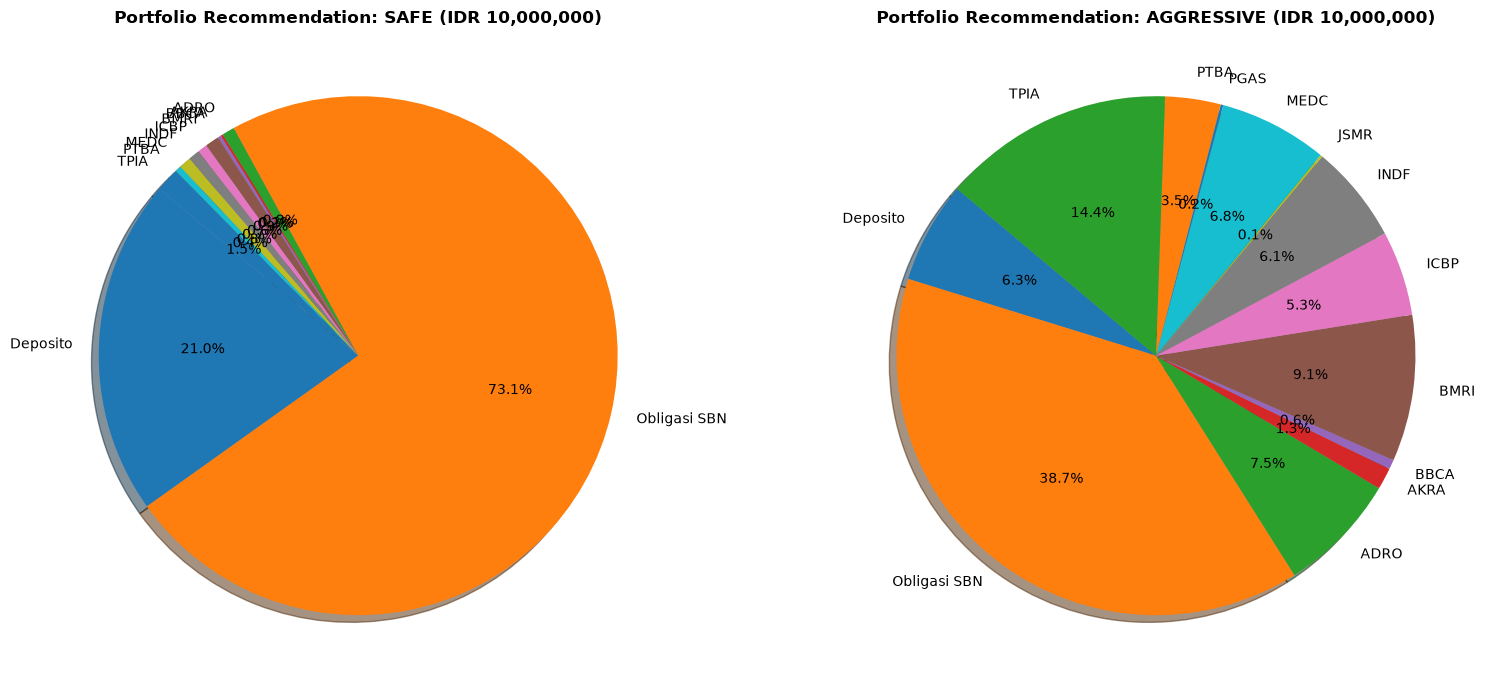

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Safe
safe_alloc = res_safe["allocation"]
safe_labels = [item["asset"] for item in safe_alloc]
safe_sizes = [float(item["percentage"].replace("%", "")) for item in safe_alloc]
axes[0].pie(safe_sizes, labels=safe_labels, autopct='%1.1f%%', startangle=140, shadow=True)
axes[0].set_title("Portfolio Recommendation: SAFE (IDR 10,000,000)", fontsize=12, fontweight='bold')

# Subplot 2: Aggressive
agg_alloc = res_agg["allocation"]
agg_labels = [item["asset"] for item in agg_alloc]
agg_sizes = [float(item["percentage"].replace("%", "")) for item in agg_alloc]
axes[1].pie(agg_sizes, labels=agg_labels, autopct='%1.1f%%', startangle=140, shadow=True)
axes[1].set_title("Portfolio Recommendation: AGGRESSIVE (IDR 10,000,000)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Parallel Computing Performance Benchmarking
Core Academic Section: We compare 6 computational backends in evaluating Sharpe Ratios for 1,000 portfolio combinations, and verify the numeric consistency of the results.

In [ ]:
from backend.benchmark.runner import run_benchmark

df_returns_dynamic = df_prices.pct_change().dropna()
T_ret = len(df_returns_dynamic)
deposito_daily_ret = bi_rate / 252.0
sbn_daily_ret = sbn_rate / 252.0

df_returns = pd.DataFrame(index=df_returns_dynamic.index)
df_returns["DEPOSITO"] = np.full(T_ret, deposito_daily_ret)
df_returns["SBN ORI"] = np.full(T_ret, sbn_daily_ret)
for col in df_returns_dynamic.columns:
    df_returns[col] = df_returns_dynamic[col]
    
asset_names = df_returns.columns.tolist()
mu = df_returns.mean().values * 252.0
mu[0] = bi_rate
mu[1] = sbn_rate
Sigma = np.cov(df_returns.values, rowvar=False) * 252.0

P_rel = np.zeros((T_ret + 1, len(asset_names)))
P_rel[0, :] = 1.0
for t in range(1, T_ret + 1):
    P_rel[t, 0] = (1.0 + deposito_daily_ret) ** t
    P_rel[t, 1] = (1.0 + sbn_daily_ret) ** t
for col_idx, col_name in enumerate(asset_names[2:], start=2):
    initial_price = df_prices[col_name].iloc[0]
    if initial_price > 0:
        P_rel[:, col_idx] = df_prices[col_name].values[:T_ret+1] / initial_price
    else:
        P_rel[:, col_idx] = 1.0

df_benchmark = run_benchmark(df_prices, mu, Sigma, P_rel, profile_name="balanced")
display(df_benchmark)

2026-06-21 19:14:14,933 - INFO - --- STARTING 6-METHOD PERFORMANCE BENCHMARK (N=28, P=1000) ---


2026-06-21 19:14:15,142 - INFO - Method 1: Sequential Python completed in 0.1985 seconds (Best Sharpe: 0.8215)


2026-06-21 19:15:01,160 - INFO - Method 2: PySpark SQL Query completed in 46.0212 seconds (Best Sharpe: 0.8215)


2026-06-21 19:15:11,218 - INFO - Method 3: PySpark RDD map completed in 10.0545 seconds (Best Sharpe: 0.8215)


2026-06-21 19:15:31,485 - INFO - Method 4: PySpark RDD filter+reduce completed in 20.2652 seconds (Best Sharpe: 0.8215)


...

2026-06-21 19:15:45,617 - INFO - --- STARTING NUMERICAL CONSISTENCY VERIFICATION ---


2026-06-21 19:15:45,619 - INFO - Maximum Sharpe Ratio difference across methods: 0.00000008


2026-06-21 19:15:45,619 - INFO - VERIFICATION SUCCESS: All executed methods yielded identical optimal Sharpe ratios! ✅


2026-06-21 19:15:45,643 - INFO - Benchmark results successfully written to: d:/INFORMATICS/SEMESTER 4/PARALLEL PROCESSING/Spark/backend/results\benchmark.csv


,Method,Time (s),Best Sharpe,Speedup
0,Sequential Python,0.198528,0.821492,1.000000
1,PySpark SQL Query,46.021207,0.821492,0.004314
2,PySpark RDD map,10.054517,0.821492,0.019745
3,PySpark RDD filter + reduce,20.265168,0.821492,0.009797
4,Pure CUDA (GPU),0.029998,0.821492,6.618004
5,PySpark + CUDA,14.099845,0.821492,0.014080


### Execution Time & Speedup Comparison Plot
Let's visualize the computation speedup of GPU & parallel CPU backends compared to Sequential Python using a bar chart.

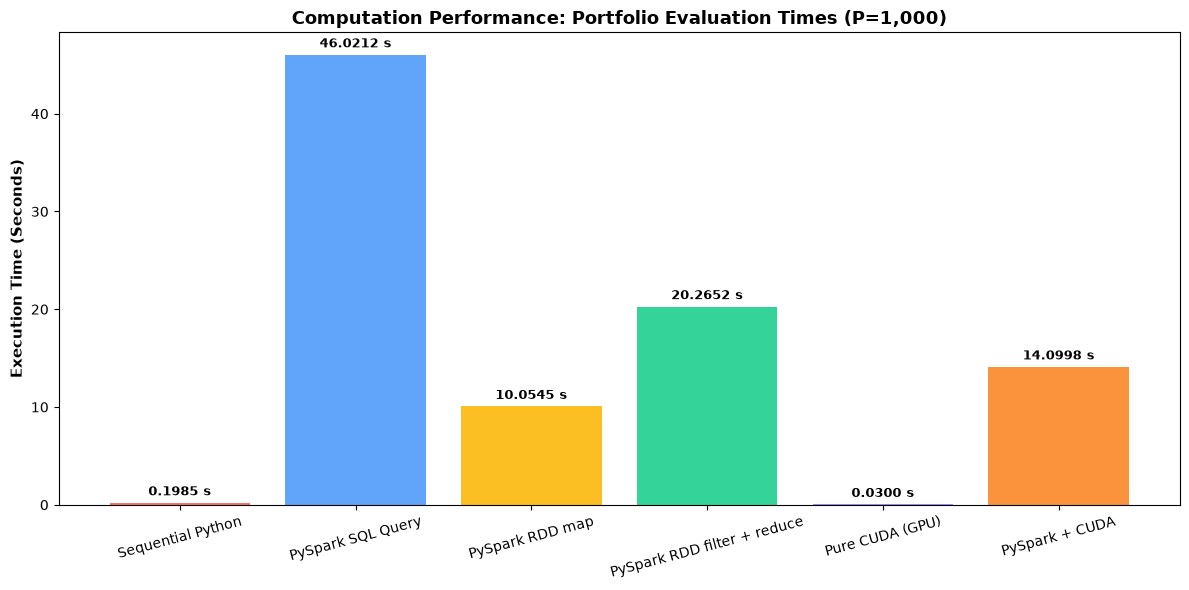


=== ACCELERATION SPEEDUP RESUME ===
Sequential Python: 0.1985 s (Speedup: 1.00x)
PySpark SQL Query: 46.0212 s (Speedup: 0.00x)
PySpark RDD map: 10.0545 s (Speedup: 0.02x)
PySpark RDD filter + reduce: 20.2652 s (Speedup: 0.01x)
Pure CUDA (GPU): 0.0300 s (Speedup: 6.62x)
PySpark + CUDA: 14.0998 s (Speedup: 0.01x)


In [6]:
plt.figure(figsize=(12, 6))
colors = ['#f87171', '#60a5fa', '#fbbf24', '#34d399', '#a78bfa', '#fb923c']

# Bar chart of execution times
bars = plt.bar(df_benchmark["Method"], df_benchmark["Time (s)"], color=colors[:len(df_benchmark)])
plt.ylabel("Execution Time (Seconds)", fontsize=11, fontweight='bold')
plt.title("Computation Performance: Portfolio Evaluation Times (P=1,000)", fontsize=13, fontweight='bold')
plt.xticks(rotation=15)

# Add numeric label on top of each bar
for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(df_benchmark["Time (s)"])*0.01), f"{yval:.4f} s", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print resume speedup
print("\n=== ACCELERATION SPEEDUP RESUME ===")
for idx, row in df_benchmark.iterrows():
    print(f"{row['Method']}: {row['Time (s)']:.4f} s (Speedup: {row['Speedup']:.2f}x)")